# 06 · Relative FEP over Loch-equilibrated waters

## Status, stated first

| Stage | Status |
|---|---|
| bound-frame selection (medoid per ligand) | **done** |
| 52-edge reference network resolved | **done** |
| `prepare_fep.py` mapping + merge, all 52 edges | **done** — mapped-heavy fraction 0.833–1.000, no charge changes |
| bound legs (52 × 11 λ windows) | **FAILED** 2026-07-24 — `CUDA_ERROR_UNSUPPORTED_PTX_VERSION (222)` on every window |
| free legs | never started (downstream of bound) |
| network fit / benchmark comparison | **not obtained** |

**There is no ΔΔG result from this branch.** What exists is a fully prepared,
validated 52-edge network and a diagnosed environment failure with a fix and a
preflight gate. §6 reproduces the diagnosis from the retained logs; §7 is the
gate that must be run before resubmitting.

A **frame-handling correctness defect** that affected *both* legs of that network
was found and **fixed on 2026-08-10** — §3 has the geometry, the fix, and the
regression tests that now guard it. Read it before resubmitting: the pre-fix
`.bss` streams and preparation markers are invalid, and one of the two frame
offsets involved was not previously documented at all.

## Why this branch exists

The whole endpoint pipeline exists to place pocket waters. Relative FEP should
therefore start from that settled state, not from a fresh solvation. That is the
bridge: `--bound-frame production` seeds each edge's bound leg from state A's
water-equilibrated production restart.

## What FEP is not

Endpoint MD/GCMC is **not** FEP, however many GCMC waters it has. Relative FEP
requires a mapped perturbable pair, bound *and* free legs, a λ schedule, and
overlap/convergence analysis. Existing endpoint trajectories contain no hidden
alchemical result and do not need rerunning because this branch was added.

## Workflow

0. Configuration
1. Environment — separate, and pinned for a reason
2. Bound-frame selection across replicates
3. **The frame-registration defect** (unfixed)
4. Edge network and selection
5. Preparation of all 52 edges — what actually succeeded
6. The failure: PTX 222
7. Preflight gate
8. Analysis and aggregation path
9. Operational traps that cost real time
10. Recap

---
## 0 · Configuration

In [1]:
from pathlib import Path

PROJECT_1 = Path("/home/moshe/intern_projects/project_1")
PROJECT_2 = Path("/home/moshe/intern_projects/project_2")

FEP_SCRIPTS = PROJECT_2 / "scripts"
FEP_RUNS = FEP_SCRIPTS / "fep-runs"          # the attempted 52-edge network
FEP_LOGS = FEP_RUNS / "_logs"
EDGE_TSV = PROJECT_2 / "fep_edges" / "rowan_xtal_edges_full.tsv"
SOMD2_CONFIG = FEP_SCRIPTS / "somd2_config.yaml"

# A locally complete endpoint run, used to reproduce the frame measurement in section 3.
ENDPOINT_RUN = PROJECT_2 / "runs" / "x7259a-rep1-full-local"

# The one FEP run that produced energy Parquets at all (a 2-window smoke).
SMOKE_FEP = PROJECT_2 / "csbrt" / "csbrt-run" / "fep-runs"

print(f"fep-runs      : {FEP_RUNS}   (exists={FEP_RUNS.is_dir()})")
print(f"edge network  : {EDGE_TSV}  (exists={EDGE_TSV.is_file()})")
print(f"endpoint run  : {ENDPOINT_RUN}  (exists={ENDPOINT_RUN.is_dir()})")
print(f"smoke fep     : {SMOKE_FEP}  (exists={SMOKE_FEP.is_dir()})")

fep-runs      : /home/moshe/intern_projects/project_2/scripts/fep-runs   (exists=True)
edge network  : /home/moshe/intern_projects/project_2/fep_edges/rowan_xtal_edges_full.tsv  (exists=True)
endpoint run  : /home/moshe/intern_projects/project_2/runs/x7259a-rep1-full-local  (exists=True)
smoke fep     : /home/moshe/intern_projects/project_2/csbrt/csbrt-run/fep-runs  (exists=True)


In [2]:
import json
import re
from collections import Counter

import numpy as np

try:
    import pandas as pd
    HAVE_PANDAS = True
except ImportError:
    HAVE_PANDAS = False

try:
    import matplotlib.pyplot as plt
    HAVE_MPL = True
except ImportError:
    HAVE_MPL = False

try:
    import parmed as pmd
    HAVE_PARMED = True
except ImportError:
    HAVE_PARMED = False

---
## 1 · Environment — separate, and pinned for a reason

FEP runs in its **own** Mamba environment, `automated-fep`, from
`environment-fep.yml` (SOMD2/OpenBioSim 2026.1). Two rules:

- **Never install SOMD2 into `cry-loch-babel`.** Never upgrade the validated
  endpoint environment in place.
- **`cuda-nvvm` is required whenever the bound leg uses Loch GCMC** — Loch
  compiles CUDA kernels at runtime, and a visible `nvcc` wrapper alone still
  fails when `cicc` is absent. The default path runs GCMC off, so it does not
  need it.

The endpoint preparation and the bound-frame averaging run in `cry-loch-babel`.

### The pin that matters

`cuda-version` must be **≤ the cluster node driver's CUDA version** — 12.8 here,
matching `cry-loch-babel`. Pin the whole toolchain, not just `cuda-version`: an
unpinned `cuda-nvcc` resolves to 12.9 and every OpenMM context creation then fails
with `CUDA_ERROR_UNSUPPORTED_PTX_VERSION (222)` while the job still exits 0.

In [3]:
# ── The SOMD2 schedule actually configured ───────────────────────────────────
if SOMD2_CONFIG.is_file():
    print(SOMD2_CONFIG.read_text())

print("""
Reading this schedule honestly:

  * 11 lambda windows x 5 ns = 55 ns of sampling PER LEG, run SERIALLY on one GPU.
    At ~700 ns/day per window that is ~2 h/leg, not '55 ns/day'.
  * `replica_exchange: false` — this is plain independent-window sampling.
  * `equilibration_time: 100 ps` per window is charged on top and must be
    included when projecting production cost.
  * This is a CONSERVATIVE STARTING POINT, not a convergence guarantee. Extend
    runtime and add windows when the overlap diagnostic demands it.
""")

# Conservative starting point, not a convergence guarantee. Extend runtime and
# add lambda windows when overlap/convergence diagnostics require it.
runtime: 5 ns
timestep: 4 fs
temperature: 300 K
pressure: 1 atm
num_lambda: 11
lambda_schedule: standard_morph
equilibration_time: 100 ps
energy_frequency: 1 ps
frame_frequency: 100 ps
checkpoint_frequency: 100 ps
save_trajectories: true
save_energy_components: false
replica_exchange: false
overwrite: false


Reading this schedule honestly:

  * 11 lambda windows x 5 ns = 55 ns of sampling PER LEG, run SERIALLY on one GPU.
    At ~700 ns/day per window that is ~2 h/leg, not '55 ns/day'.
  * `replica_exchange: false` — this is plain independent-window sampling.
  * `equilibration_time: 100 ps` per window is charged on top and must be
    included when projecting production cost.
  * This is a CONSERVATIVE STARTING POINT, not a convergence guarantee. Extend
    runtime and add windows when the overlap diagnostic demands it.



---
## 2 · Bound-frame selection across replicates

With six endpoint replicates per ligand, one representative bound frame is chosen
per ligand before any FEP.

**Do not average water Cartesian coordinates.** Waters are indistinguishable and
permute between replicates, so a coordinate mean is meaningless — and a Cartesian
mean structure is non-physical without minimisation anyway.

Two legitimate options, both emitting the same
`LIGAND/production-final.{prmtop,rst7}` layout that `--bound-frame-root` consumes:

| Script | Method | Notes |
|---|---|---|
| `select_bound_frames.py` | **medoid replicate** — the run whose common-catalogue hydration-site occupancy is closest to the per-ligand mean | returns one *real* replicate endpoint; inspect `selection_report.csv` for the chosen replicate and the spread |
| `build_consensus_frames.py` | **density-based consensus placement** (cf. GIST / 3D-RISM / WATsite) — keep the medoid's protein/ligand/bulk, snap in-sphere pocket waters onto the all-replicate consensus sites by optimal assignment, then minimise | topology unchanged from the medoid, so it inherits the ghost-free guarantee; no prmtop surgery |

Consensus differs from the medoid **only** in pocket-water placement, which is the
clean way to test whether that placement matters. In practice the displacements
are small — well-agreed replicates already sit near the consensus peaks — so the
two are usually close.

### ⚠ `select_bound_frames.py` symlinks by default

`--copy` is opt-in. A tarball built from `bound_frames/` therefore archives
**dangling links, not data** — a 2.3 KB `medoids.tgz` is the signature of exactly
this. Use `tar czhf` (dereference) or `--copy` at selection time, and check with
`du -h` before transferring: the real payload is ~115 MB, not kilobytes.

In [4]:
# ── Which replicate seeded each edge's bound leg ─────────────────────────────
setups = sorted(FEP_RUNS.glob("*/setup/fep_preparation.complete.json")) if FEP_RUNS.is_dir() else []
records = []
for p in setups:
    d = json.loads(p.read_text())
    bound = d.get("bound_input_coordinates") or ""
    parts = Path(bound).parts
    ligand = replica = None
    if len(parts) >= 4:
        ligand, replica = parts[-4], parts[-3]
    records.append(dict(
        edge=d["edge_id"], state_a=d["edge_id"].split("_to_")[0],
        state_b=d["edge_id"].split("_to_")[-1],
        mapped_atoms=d.get("mapped_atoms"), mapped_heavy=d.get("mapped_heavy_atoms"),
        mapped_heavy_fraction=d.get("mapped_heavy_fraction"),
        charge_change=d.get("charge_change"),
        align_to_bound_pose=d.get("align_to_bound_pose"),
        bound_ligand=ligand, bound_replica=replica,
        allow_ring_breaking=d.get("allow_ring_breaking"),
        biosimspace=d.get("implementation", {}).get("module_versions", {}).get("BioSimSpace"),
    ))

if records and HAVE_PANDAS:
    PREP_DF = pd.DataFrame(records)
    print(f"edges with completed preparation: {len(PREP_DF)} / {len(list(FEP_RUNS.glob('*/setup')))}")
    print(f"\nmedoid replicate chosen per ligand (state A of each edge):")
    chosen = (PREP_DF.dropna(subset=["bound_ligand"])
                  .drop_duplicates(subset=["bound_ligand"])
                  .sort_values("bound_ligand")[["bound_ligand", "bound_replica"]])
    for i in range(0, len(chosen), 6):
        chunk = chosen.iloc[i:i + 6]
        print("   " + "   ".join(f"{r.bound_ligand}:{r.bound_replica}"
                                 for r in chunk.itertuples()))
    print(f"\n  distinct ligands seeded: {chosen['bound_ligand'].nunique()}")
    print(f"  replicate usage        : "
          f"{dict(Counter(chosen['bound_replica']).most_common())}")
    print(f"\n  ^ these are MEDOID replicates, not replicate 1 -- the selection is")
    print(f"    driven by hydration-site occupancy consensus, so the chosen index")
    print(f"    varies per ligand. That variation is the expected signature of a")
    print(f"    real medoid selection; all-rep1 would mean the selection no-oped.")
else:
    print("no preparation records found")

edges with completed preparation: 52 / 52

medoid replicate chosen per ligand (state A of each edge):
   x6738a:rep5   x6832a:rep4   x7011a:rep1   x7024a:rep1   x7025a:rep3   x7026a:rep3
   x7031a:rep3   x7056a:rep4   x7093a:rep5   x7127a:rep1   x7132a:rep5   x7135a:rep1
   x7147a:rep6   x7161a:rep1   x7175a:rep2   x7190a:rep4   x7247a:rep4   x7257a:rep6
   x7259a:rep5   x7309a:rep2   x7316a:rep2   x7317a:rep2   x7433a:rep5   x7475a:rep2
   x7491a:rep5

  distinct ligands seeded: 25
  replicate usage        : {'rep5': 6, 'rep1': 5, 'rep2': 5, 'rep4': 4, 'rep3': 3, 'rep6': 2}

  ^ these are MEDOID replicates, not replicate 1 -- the selection is
    driven by hydration-site occupancy consensus, so the chosen index
    varies per ligand. That variation is the expected signature of a
    real medoid selection; all-rep1 would mean the selection no-oped.


---
## 3 · Three coordinate frames, and the fix

**This is the most important section in this notebook.**

Three frames are in play, and **neither leg keeps the parameterisation frame**.
The cell below re-measures all of it from a locally retained endpoint run.

| Object | Frame | Offset from the ligand input frame |
|---|---|---|
| `ligand.prmtop` / `.rst7` / `.mol2`, `ligand_input.sdf` | ligand **input** | 0 |
| bound system — prepared complex **or** production restart | **receptor** | **28.97 Å** |
| free system after `solvateOct` | tLEaP's **re-centred box** | **12.5 Å** |

Not drift and not imaging: over 10 ns the protein Cα RMSD is 0.66 Å and the ligand
1.18 Å.

### The second offset, which was missed

The 29 Å bound offset was known and documented. The **12.5 Å free offset was not**:
`solvateOct` translates the solute when it builds the octahedral box, so the free
leg is *not* in the mol2 frame either.

Placing the "correct" unaligned merge into that box put **47 of 62 ligand atoms
within 2.0 Å of a water oxygen** — closest contact **0.73 Å**, against **3.22 Å**
for the correctly placed ligand, in a 36 Å box. So the free legs of the
2026-07-24 network were sterically broken too, not just the bound legs.

That also corrects a piece of guidance: *"a rigid translation of the solute in a
periodic box is a symmetry operation"* is true only into **equivalent** solvent.
PBC makes absolute position irrelevant; it does **not** repair an overlap.

### The fix — one rule instead of a flag

`build_leg_merge()` builds **one merge per leg, RMSD-aligned onto the ligand it
replaces in that leg**. One rule, no flags, all three frames handled. Both merges
are built *after* both boxes exist, because the free box's ligand position is
tLEaP's, not the mol2's. `BSS.Align.rmsdAlign` returns a new molecule rather than
mutating its argument, so the two legs cannot contaminate each other. Measured
residual alignment error: **~3 × 10⁻¹⁴ Å**.

`--align-to-bound-pose` is now **deprecated and ignored**, still accepted so
`fep_edge.slurm` and `fep_prepare.slurm` keep working unchanged. It could only ever
select between "bound correct, free broken" and "free less broken, bound 29 Å
outside the pocket" — there was no correct setting.

### Why this needs a guard, not care

Neither mistake raises on its own:

- a **bound**-leg ligand parked in bulk solvent **minimises cleanly**;
- a displaced **free**-leg ligand surfaces only later as *"could not minimise while
  simultaneously satisfying the constraints"* — which the operational notes used to
  send you to blame on the perturbable pair.

`verify_leg_frame()` therefore runs on **both** legs — checking one cannot
distinguish a real fix from alignment disabled everywhere — and records
`frame_check.*` in the checkpoint, so a completed preparation carries the evidence.
Tolerance is `--max-leg-centroid-offset`, default 1.0 Å. **Do not raise it to make a
run pass.** `bound_to_free_separation_angstrom` is *expected* to be large (~24 Å):
the legs live in different boxes.

Fixed in all seven copies of `prepare_fep.py` (`project_2/scripts`,
`project_2/csbrt/{scripts,src/csbrt}`, `project_2/scripts/fep_for_aldo`,
`project_2/loch_fep_pipeline/scripts`, `project_1/scripts/automated_pipeline`, and
`csbrt-gcmc-fep/csbrt/src/csbrt`), with stale `__pycache__` bytecode removed.

In [5]:
# ── Reproduce the frame measurement on a locally retained endpoint run ───────
def mol2_centroid(path):
    xyz, in_atoms = [], False
    for line in Path(path).read_text().splitlines():
        if line.startswith("@<TRIPOS>ATOM"):
            in_atoms = True
            continue
        if in_atoms and line.startswith("@<TRIPOS>"):
            break
        if in_atoms and line.strip():
            f = line.split()
            xyz.append([float(f[2]), float(f[3]), float(f[4])])
    return np.asarray(xyz).mean(axis=0), len(xyz)


def sdf_centroid(path):
    lines = Path(path).read_text().splitlines()
    n = int(lines[3][0:3])
    xyz = [[float(lines[4 + i][0:10]), float(lines[4 + i][10:20]),
            float(lines[4 + i][20:30])] for i in range(n)]
    return np.asarray(xyz).mean(axis=0), n


PREFIX = "ev71_2a_x7259a"
PREP_DIR = ENDPOINT_RUN / "preparation"
PROD_DIR = ENDPOINT_RUN / "production"

if HAVE_PARMED and PREP_DIR.is_dir():
    frames = {}
    frames["ligand_input.sdf"] = sdf_centroid(PREP_DIR / "ligand_input.sdf")[0]
    frames["ligand.mol2"] = mol2_centroid(PREP_DIR / "ligand.mol2")[0]

    lr = pmd.load_file(str(PREP_DIR / "ligand.prmtop"), xyz=str(PREP_DIR / "ligand.rst7"))
    frames["ligand.rst7"] = np.array([[a.xx, a.xy, a.xz] for a in lr.atoms]).mean(axis=0)

    def complex_centroids(top, crd):
        s = pmd.load_file(str(top), xyz=str(crd))
        lig = [r for r in s.residues if r.name == "LIG"][0]
        lig_xyz = np.array([[a.xx, a.xy, a.xz] for a in lig.atoms])
        ca = [a for a in s.atoms
              if a.name == "CA" and a.residue.name not in ("WAT", "LIG")]
        ca_xyz = np.array([[a.xx, a.xy, a.xz] for a in ca])
        return lig_xyz, ca_xyz

    sol_lig, sol_ca = complex_centroids(PREP_DIR / f"{PREFIX}_solvated.prmtop",
                                       PREP_DIR / f"{PREFIX}_solvated.inpcrd")
    pro_lig, pro_ca = complex_centroids(PROD_DIR / f"{PREFIX}-production-final.prmtop",
                                       PROD_DIR / f"{PREFIX}-production-final.rst7")
    frames["solvated complex LIG"] = sol_lig.mean(axis=0)
    frames["production-final LIG"] = pro_lig.mean(axis=0)

    W = 74
    print("╔" + "═" * W + "╗")
    print("║ " + f"{'LIGAND CENTROID BY FILE — ' + PREFIX:^{W - 1}}"[:W - 1] + "║")
    print("╠" + "═" * W + "╣")
    for k, v in frames.items():
        print("║ " + f"{k:<26}[{v[0]:8.2f} {v[1]:8.2f} {v[2]:8.2f}]".ljust(W - 1) + "║")
    print("╚" + "═" * W + "╝")

    off = float(np.linalg.norm(frames["ligand.mol2"] - frames["solvated complex LIG"]))
    print(f"\n  ligand.mol2 / .rst7 / _input.sdf -> solvated complex : {off:.2f} A")
    print(f"  the three parameterization files agree to "
          f"{np.abs(frames['ligand_input.sdf'] - frames['ligand.rst7']).max():.4f} A "
          "-- they are ONE frame, and it is not the receptor's")

    # Rule out MD drift and imaging: superpose on CA, then measure the ligand.
    def kabsch_apply(mobile_ca, target_ca, mobile_pts):
        mc, tc = mobile_ca.mean(0), target_ca.mean(0)
        V, S, Wt = np.linalg.svd((mobile_ca - mc).T @ (target_ca - tc))
        d = np.sign(np.linalg.det(V @ Wt))
        R = (V @ np.diag([1.0, 1.0, d]) @ Wt).T
        rmsd = float(np.sqrt(np.mean(np.sum(
            ((mobile_ca - mc) @ R.T + tc - target_ca) ** 2, axis=1))))
        return (mobile_pts - mc) @ R.T + tc, rmsd

    pro_lig_on_sol, ca_rmsd = kabsch_apply(pro_ca, sol_ca, pro_lig)
    lig_drift = float(np.sqrt(np.mean(np.sum((pro_lig_on_sol - sol_lig) ** 2, axis=1))))
    print(f"""
  Ruling out drift and imaging, solvation -> end of 10 ns production:
      protein CA RMSD after superposition : {ca_rmsd:.2f} A
      ligand RMSD in the CA-aligned frame : {lig_drift:.2f} A

  Both are of order 1-2 A. The {off:.1f} A separation is therefore a COORDINATE-FRAME
  difference between the parameterization files and the receptor, not motion.
""")
else:
    print("parmed unavailable or endpoint run absent — see the reference values below")
    print("""
  Reference, measured 2026-07-31 on runs/x7259a-* (three runs, identical result):
      ligand_input.sdf / ligand.mol2 / ligand.rst7 : [ 7.8, 13.2, 24.8]
      same ligand inside the solvated complex      : [19.5, 39.1, 30.5]
      separation                                   : 28.97 A
      protein centroid motion, solvation -> end    :  1.08 A
      in-complex ligand motion                     :  ~1.3 A
""")

╔══════════════════════════════════════════════════════════════════════════╗
║                 LIGAND CENTROID BY FILE — ev71_2a_x7259a                 ║
╠══════════════════════════════════════════════════════════════════════════╣
║ ligand_input.sdf          [    7.84    13.24    24.76]                   ║
║ ligand.mol2               [    7.84    13.24    24.76]                   ║
║ ligand.rst7               [    7.84    13.24    24.76]                   ║
║ solvated complex LIG      [   19.53    39.12    30.50]                   ║
║ production-final LIG      [   17.01    34.86    33.38]                   ║
╚══════════════════════════════════════════════════════════════════════════╝

  ligand.mol2 / .rst7 / _input.sdf -> solvated complex : 28.97 A
  the three parameterization files agree to 0.0001 A -- they are ONE frame, and it is not the receptor's

  Ruling out drift and imaging, solvation -> end of 10 ns production:
      protein CA RMSD after superposition : 0.66 A
      ligand R

### 3b · End-to-end check — run the fixed `prepare_fep.py` on a null perturbation

A null perturbation (state A → state A) is the guaranteed-to-merge minimal case, so
it isolates the frame handling from mapping difficulty. This runs the **real**
script on the retained local endpoint preparation, then checks the geometry of both
streams it produced.

Needs `tleap` and BioSimSpace in the running kernel and takes about a minute; it
reports and skips otherwise. Output goes to a temporary directory.

In [6]:
# ── Run the real prepare_fep.py on a null edge ───────────────────────────────
import os
import sys
import shutil
import subprocess
import tempfile

NULL_EDGE = None
prep_dir = ENDPOINT_RUN / "preparation"
script = FEP_SCRIPTS / "prepare_fep.py"

# Resolve tleap the same way prepare_fep.py does: PATH first, then the sibling of
# the running interpreter. A Jupyter kernel usually inherits the launching shell's
# PATH rather than its own environment's bin/, so the sibling lookup is the one that
# actually finds it here.
env_bin = Path(sys.executable).resolve().parent
tleap_path = shutil.which("tleap") or (
    str(env_bin / "tleap") if (env_bin / "tleap").is_file() else None
)

if not (script.is_file() and prep_dir.is_dir()):
    print(f"skipped: need {script} and {prep_dir}")
elif tleap_path is None:
    print(f"skipped: tleap not found on PATH or beside {sys.executable}")
else:
    print(f"tleap: {tleap_path}")
    NULL_EDGE = Path(tempfile.mkdtemp(prefix="nb06_null_")) / "null"
    cmd = [
        sys.executable, "-u", str(script),
        "--state-a-preparation", str(prep_dir),
        "--state-b-preparation", str(prep_dir),
        "--output-dir", str(NULL_EDGE),
        "--edge-id", "nb06_null",
        # Passed deliberately: it must be accepted and IGNORED, so the existing
        # wrappers keep working without silently changing behaviour.
        "--align-to-bound-pose",
    ]
    print(" ".join(cmd[1:]))
    print()
    # Put the interpreter's own bin/ on PATH so the child's tleap lookup succeeds.
    child_env = dict(os.environ)
    child_env["PATH"] = f"{env_bin}{os.pathsep}{child_env.get('PATH', '')}"
    result = subprocess.run(
        cmd, capture_output=True, text=True, cwd=str(FEP_SCRIPTS), env=child_env
    )
    for line in result.stdout.splitlines():
        if line.startswith("[prepare_fep]") or line.startswith("FEP_PREPARATION="):
            print(line)
    if result.returncode != 0:
        print(f"FAILED (exit {result.returncode})")
        print(result.stdout[-1200:])
        print(result.stderr[-1200:])
        NULL_EDGE = None
    else:
        marker = json.loads((NULL_EDGE / "fep_preparation.complete.json").read_text())
        fc = marker["frame_check"]
        print()
        print("recorded frame_check:")
        print(f"    {'tolerance_angstrom':<38} {fc['tolerance_angstrom']}")
        print(f"    {'bound_centroid_offset_angstrom':<38} "
              f"{fc['bound_centroid_offset_angstrom']:.3e}")
        print(f"    {'free_centroid_offset_angstrom':<38} "
              f"{fc['free_centroid_offset_angstrom']:.3e}")
        print(f"    {'bound_to_free_separation_angstrom':<38} "
              f"{fc['bound_to_free_separation_angstrom']:.2f}   "
              "(expected to be large: separate boxes)")
        print(f"    {'bound_alignment':<38} {marker['bound_alignment']}")
        print(f"    {'align_to_bound_pose_flag_ignored':<38} "
              f"{marker['align_to_bound_pose_flag_ignored']}")
        assert fc["bound_centroid_offset_angstrom"] < 1e-6
        assert fc["free_centroid_offset_angstrom"] < 1e-6
        print()
        print("  both legs aligned to machine precision; the deprecated flag was ignored")

tleap: /home/moshe/miniforge3/envs/csbrt/bin/tleap
-u /home/moshe/intern_projects/project_2/scripts/prepare_fep.py --state-a-preparation /home/moshe/intern_projects/project_2/runs/x7259a-rep1-full-local/preparation --state-b-preparation /home/moshe/intern_projects/project_2/runs/x7259a-rep1-full-local/preparation --output-dir /tmp/nb06_null_ax3zi02p/null --edge-id nb06_null --align-to-bound-pose



[prepare_fep] --align-to-bound-pose is deprecated and ignored: each leg's merge is now always aligned onto the ligand it replaces in that leg.
[prepare_fep] frame check: bound offset 0.000 A, free offset 0.000 A, bound-to-free separation 23.64 A [expected to be large: separate boxes] (tolerance 1.00 A)
FEP_PREPARATION=/tmp/nb06_null_ax3zi02p/null/fep_preparation.complete.json

recorded frame_check:
    tolerance_angstrom                     1.0
    bound_centroid_offset_angstrom         2.041e-14
    free_centroid_offset_angstrom          1.628e-14
    bound_to_free_separation_angstrom      23.64   (expected to be large: separate boxes)
    bound_alignment                        unconditional_to_bound_frame_ligand_pose
    align_to_bound_pose_flag_ignored       True

  both legs aligned to machine precision; the deprecated flag was ignored


In [7]:
# ── The physically meaningful check: no steric clash in either stream ────────
# This is what distinguishes a harmless rigid translation from a real overlap, and
# it is the measurement that exposed the free-leg defect: 0.73 A closest contact
# with 47 of 62 atoms inside 2.0 A, before the fix.
if NULL_EDGE is None:
    print("skipped: no null-edge run available")
else:
    import BioSimSpace as BSS

    def coordinates(molecule):
        if molecule.isPerturbable():
            molecule = molecule._toRegularMolecule(is_lambda1=False)
        out = []
        for atom in molecule.getAtoms():
            c = atom.coordinates()
            out.append([c.x().angstroms().value(), c.y().angstroms().value(),
                        c.z().angstroms().value()])
        return np.asarray(out)

    print(f"{'leg':<7}{'molecules':>11}{'waters':>8}{'lig atoms':>11}"
          f"{'min lig-water O':>17}{'atoms < 2.0 A':>15}")
    print("-" * 70)
    for leg in ("bound", "free"):
        system = BSS.Stream.load(str(NULL_EDGE / f"nb06_null_{leg}.bss"))
        perturbable = [i for i, m in enumerate(system.getMolecules()) if m.isPerturbable()]
        assert len(perturbable) == 1, f"{leg} leg lost its perturbable molecule"
        ligand = coordinates(system.getMolecule(perturbable[0]))
        oxygens = np.asarray([
            coordinates(m)[0] for m in system.getMolecules()
            if not m.isPerturbable() and m.nAtoms() == 3
            and m.getResidues()[0].name() in ("WAT", "HOH")
        ])
        distances = np.linalg.norm(ligand[:, None, :] - oxygens[None, :, :], axis=2)
        closest = float(distances.min())
        clashes = int((distances.min(axis=1) < 2.0).sum())
        print(f"{leg:<7}{system.nMolecules():>11,}{len(oxygens):>8,}{len(ligand):>11}"
              f"{closest:>17.2f}{clashes:>15}")
        assert clashes == 0, f"{leg} leg ligand overlaps water"
        assert closest > 2.5, f"{leg} leg closest contact {closest:.2f} A is too short"

    print()
    print("  Both legs sit in their own cavity with no overlap. Before the fix the free")
    print("  leg read 0.73 A closest contact with 47 of 62 atoms inside 2.0 A -- a hard")
    print("  clash that surfaces as a minimisation failure and gets blamed on the mapping.")

<frozen importlib._bootstrap>:488: RuntimeWarning: to-Python converter for std::vector<double, std::allocator<double> > already registered; second conversion method ignored.


leg      molecules  waters  lig atoms  min lig-water O  atoms < 2.0 A
----------------------------------------------------------------------


bound        4,575   4,570         57             3.30              0


free         1,015   1,014         57             3.16              0

  Both legs sit in their own cavity with no overlap. Before the fix the free
  leg read 0.73 A closest contact with 47 of 62 atoms inside 2.0 A -- a hard
  clash that surfaces as a minimisation failure and gets blamed on the mapping.


### 3d · Why the defect survived its own self-test — a null perturbation is blind to it

The 2026-07-31 change was validated with a **null perturbation** (x7259a → x7259a,
identity mapping over all 57 atoms). That test is **mathematically insensitive to
where the ligand sits**: with state A identical to state B, any environment error —
vacuum, overlapping water, wrong pocket — contributes identically at λ=0 and λ=1 and
cancels exactly in ΔΔG.

Recovered from that run's retained artefacts and re-analysed:

| | value |
|---|---|
| free-leg ligand vs its own tLEaP box | **0.56 Å** closest water O · **33 of 57 atoms inside 2.0 Å** |
| free-leg minimisation failures | **0** |
| windows completed | 11/11 bound · 11/11 free |
| ΔΔG measured | **−0.0001 ± 0.0001 kcal/mol** |
| ΔΔG true | 0.000 |

So it returned the right answer *through* a severely clashing free leg, and read as
a pass. For a **real** edge the cancellation fails — dummy atoms appear and
disappear and the perturbed atoms' interactions with their environment change, so a
wrong environment gives a wrong ΔG_free and hence a wrong ΔΔG.

**What to take from this.** Keep the null perturbation for the *run path* only: does
a leg complete, are all Parquets written. Use `frame_check` for the *geometry* — it
does not depend on the perturbation being non-trivial, which is exactly why it
catches what the null test cannot. And note the general shape, which recurs
throughout this handover: **completion plus a plausible number is not validation.**

### 3c · The guard must reject all three historical mistakes

A guard that never fires is not a guard. Each case below is a frame mistake that has
actually occurred in this pipeline.

In [8]:
# ── Negative and positive tests of verify_leg_frame ──────────────────────────
import math

if NULL_EDGE is None:
    print("skipped: no null-edge run available")
else:
    sys.path.insert(0, str(FEP_SCRIPTS))
    import BioSimSpace as BSS
    import prepare_fep as P

    lig_a = P.ligand_from_preparation(prep_dir)
    lig_b = P.ligand_from_preparation(prep_dir)
    ident = {i: i for i in range(lig_a.nAtoms())}

    bound_sys = BSS.IO.readMolecules([
        str(prep_dir / f"{PREFIX}_solvated.prmtop"),
        str(prep_dir / f"{PREFIX}_solvated.inpcrd"),
    ])
    bi = P.ligand_index(bound_sys)
    bound_target = P.centroid(bound_sys.getMolecule(bi))

    # The free box built by the run in 3b: tLEaP's re-centred frame, same ligand.
    free_sys = BSS.IO.readMolecules([
        str(NULL_EDGE / "state_a_free.prmtop"), str(NULL_EDGE / "state_a_free.rst7")
    ])
    fi = P.ligand_index(free_sys)
    free_target = P.centroid(free_sys.getMolecule(fi))
    input_centroid = P.centroid(lig_a)
    print(f"ligand input centroid {np.round(input_centroid, 2)}")
    print(f"bound target centroid {np.round(bound_target, 2)}   "
          f"({math.dist(bound_target, input_centroid):.2f} A from input)")
    print(f"free  target centroid {np.round(free_target, 2)}   "
          f"({math.dist(free_target, input_centroid):.2f} A from input -- tLEaP re-centred)")

    unaligned = BSS.Align.merge(lig_a, BSS.Align.rmsdAlign(lig_b, lig_a, ident), ident)
    bound_merge = P.build_leg_merge("bound", bound_sys, bi, lig_a, lig_b, ident, ident,
                                    allow_ring_breaking=False, allow_ring_size_change=False)
    cases = [
        ("bound", unaligned, bound_target,
         "unaligned merge on the BOUND leg (old flag off: outside the pocket)"),
        ("free", unaligned, free_target,
         "unaligned merge on the FREE leg  (the offset that was missed)"),
        ("free", bound_merge, free_target,
         "bound merge on the FREE leg      (old flag on: outside the water cavity)"),
    ]

    print()
    print("NEGATIVE TESTS")
    print("-" * 76)
    not_rejected = 0
    for leg, merged, target, label in cases:
        try:
            offset = P.verify_leg_frame(leg, merged, target, 1.0)
            print(f"  !! NOT REJECTED at {offset:.2f} A - {label}")
            not_rejected += 1
        except RuntimeError as exc:
            measured = str(exc).split(" from the")[0].split("is ")[-1]
            print(f"  ok rejected at {measured:<8} - {label}")

    print()
    print("POSITIVE CONTROL")
    print("-" * 76)
    for leg, system, index, target in (("bound", bound_sys, bi, bound_target),
                                       ("free", free_sys, fi, free_target)):
        merged = P.build_leg_merge(leg, system, index, lig_a, lig_b, ident, ident,
                                   allow_ring_breaking=False, allow_ring_size_change=False)
        offset = P.verify_leg_frame(leg, merged, target, 1.0)
        print(f"  ok {leg:<6} correct per-leg merge accepted at {offset:.2e} A")

    assert not_rejected == 0, "the frame guard failed to reject a known-bad frame"
    print()
    print(f"  {len(cases)} negative + 2 positive checks passed")

/home/moshe/miniforge3/envs/csbrt/lib/python3.12/site-packages/BioSimSpace/IO/_io.py:421: UserWarning: BioSimSpace.IO: Please install GROMACS (http://www.gromacs.org) for GROMACS topology file support.
  _warnings.warn(


ligand input centroid [ 7.84 13.24 24.76]
bound target centroid [19.53 39.12 30.5 ]   (28.97 A from input)
free  target centroid [17.38 18.53 19.08]   (12.30 A from input -- tLEaP re-centred)



NEGATIVE TESTS
----------------------------------------------------------------------------
  ok rejected at 28.97 A  - unaligned merge on the BOUND leg (old flag off: outside the pocket)
  ok rejected at 12.30 A  - unaligned merge on the FREE leg  (the offset that was missed)
  ok rejected at 23.64 A  - bound merge on the FREE leg      (old flag on: outside the water cavity)

POSITIVE CONTROL
----------------------------------------------------------------------------


  ok bound  correct per-leg merge accepted at 1.28e-14 A


  ok free   correct per-leg merge accepted at 2.30e-14 A

  3 negative + 2 positive checks passed


---
## 4 · Edge network and selection

**Do not run all-to-all.** 32 ligands is 496 pairs. Reuse a published reference
network instead, so every ΔΔG is directly 1:1 comparable to a published value.

The Rowan OpenBind EV-A71 XTAL graph is provided in three sizes:

| File | Edges | Use |
|---|---|---|
| `rowan_xtal_edges_full.tsv` | **52** | connected, 21 independent cycles — the production network |
| `rowan_xtal_edges_starter_spanning.tsv` | 32 | spanning tree, minimum connected |
| `rowan_xtal_edges_demo8.tsv` | 7 | validation subset |

To shrink a network *properly*, use optimal design rather than an arbitrary
subset: `aggregate_fep_network.py` already computes the network covariance
`pinv(Wᵀ W)`, whose diagonal is each ligand's ΔG variance. Greedily add the edge
that most reduces `trace(covariance)` (A-optimal; Bayesian A-optimality under a
Gaussian prior — Xu 2019 JCIM). `select_fep_edges.py` implements this, starting
from a maximum-reliability spanning tree so every component is connected and
full-rank by construction — otherwise the aggregator raises *"FEP component is
underdetermined"*.

Two details in that selector that are not cosmetic:

- Edge noise is a **prior, not a fitted model**:
  `sigma = reference_sigma / mapped_heavy_fraction`, default 0.3 kcal/mol at
  fraction 1.0. Every candidate goes into a ledger with `observed_*` left `None`,
  so real FEP outcomes can replace the prior later. Fill those in rather than
  re-deriving the prior.
- `--min-relative-gain` (default 0.02) is the knee cutoff. Past the spanning tree
  every extra edge lowers the trace *a little*, so without it the greedy loop
  selects the entire candidate set and selection accomplishes nothing.
- `edge_index` must renumber contiguously from 0 — `fep_edge.slurm` maps it
  directly onto `SLURM_ARRAY_TASK_ID` and hard-fails on a mismatch.

In [9]:
# ── The network, and its graph properties ────────────────────────────────────
if EDGE_TSV.is_file() and HAVE_PANDAS:
    edges = pd.read_csv(EDGE_TSV, sep="\t")
    nodes = sorted(set(edges["state_a"]) | set(edges["state_b"]))
    print(f"edges: {len(edges)}   ligands: {len(nodes)}")

    # Connectivity and cycle count, without networkx.
    parent = {n: n for n in nodes}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    for a, b in zip(edges["state_a"], edges["state_b"]):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb
    comps = len({find(n) for n in nodes})
    cycles = len(edges) - len(nodes) + comps
    print(f"connected components : {comps}   (1 = every DDG is comparable)")
    print(f"independent cycles   : {cycles}   (cycle closure is the consistency check)")

    deg = Counter(list(edges["state_a"]) + list(edges["state_b"]))
    print(f"degree               : min {min(deg.values())}, "
          f"median {int(np.median(list(deg.values())))}, max {max(deg.values())}")
    print(f"all-to-all would be  : {len(nodes) * (len(nodes) - 1) // 2} pairs "
          f"-> {len(edges)} chosen ({len(edges) / (len(nodes) * (len(nodes) - 1) / 2) * 100:.1f}%)")
    assert comps == 1, "network is disconnected — some DDGs would not be comparable"

edges: 52   ligands: 32
connected components : 1   (1 = every DDG is comparable)
independent cycles   : 21   (cycle closure is the consistency check)
degree               : min 1, median 3, max 9
all-to-all would be  : 496 pairs -> 52 chosen (10.5%)


---
## 5 · Preparation of all 52 edges — what actually succeeded

Mapping and merge are the part that is chemistry-hard, and they worked. Both
edge gates are **pure chemistry** and re-docking cannot change either: formal
charge equality, and `mapped_heavy_fraction = mapped_heavy / min(heavy_a, heavy_b)`
via `BSS.Align.matchAtoms`, default minimum 0.50.

╔════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                  prepare_fep.py — ALL 52 EDGES                                 ║
╠════════════════════════════════════════════════════════════════════════════════════════════════╣
║ edges prepared          52 / 52                                                                ║
║ charge changes          [0] (all neutral-to-neutral)                                           ║
║ ring breaking allowed   [False]                                                                ║
║ align_to_bound_pose     [True]  <- see section 3                                               ║
║ mapped heavy fraction   min 0.833  median 0.962  max 1.000                                     ║
║ mapped heavy atoms      min 25  median 26  max 31                                              ║
║ BioSimSpace             ['2026.1.0']                                                           ║
╚═════════

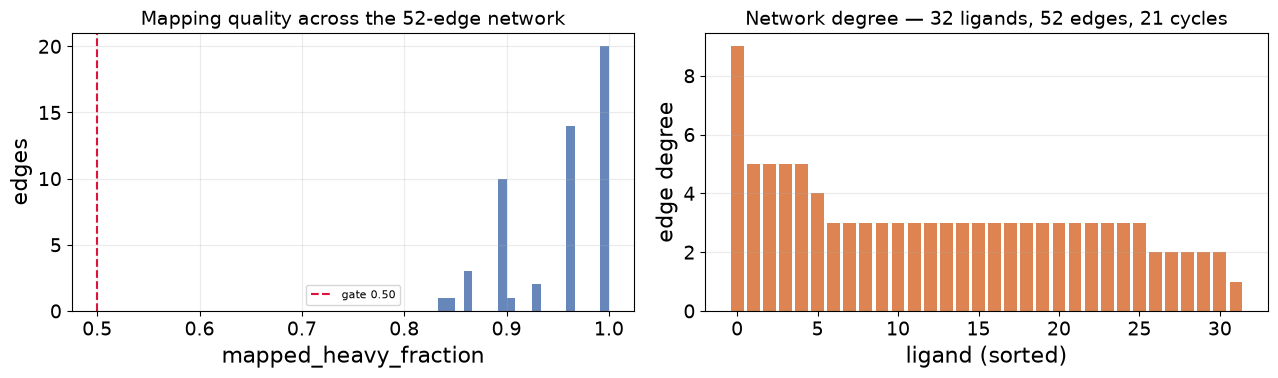

In [10]:
if records and HAVE_PANDAS:
    W = 96
    print("╔" + "═" * W + "╗")
    print("║ " + f"{'prepare_fep.py — ALL 52 EDGES':^{W - 1}}"[:W - 1] + "║")
    print("╠" + "═" * W + "╣")
    rows = [
        ("edges prepared", f"{len(PREP_DF)} / {len(PREP_DF)}"),
        ("charge changes", f"{sorted(set(PREP_DF['charge_change']))} (all neutral-to-neutral)"),
        ("ring breaking allowed", f"{sorted(set(PREP_DF['allow_ring_breaking']))}"),
        ("align_to_bound_pose", f"{sorted(set(PREP_DF['align_to_bound_pose']))}  <- see section 3"),
        ("mapped heavy fraction", f"min {PREP_DF['mapped_heavy_fraction'].min():.3f}  "
                                  f"median {PREP_DF['mapped_heavy_fraction'].median():.3f}  "
                                  f"max {PREP_DF['mapped_heavy_fraction'].max():.3f}"),
        ("mapped heavy atoms", f"min {PREP_DF['mapped_heavy'].min()}  "
                               f"median {int(PREP_DF['mapped_heavy'].median())}  "
                               f"max {PREP_DF['mapped_heavy'].max()}"),
        ("BioSimSpace", f"{sorted(set(PREP_DF['biosimspace'].dropna()))}"),
    ]
    for label, value in rows:
        print("║ " + f"{label:<24}{value}".ljust(W - 1) + "║")
    print("╚" + "═" * W + "╝")

    weakest = PREP_DF.nsmallest(6, "mapped_heavy_fraction")[
        ["edge", "mapped_heavy", "mapped_heavy_fraction"]]
    print("\nweakest-mapped edges (still far above the 0.50 gate):")
    print(weakest.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

    if HAVE_MPL:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))
        axes[0].hist(PREP_DF["mapped_heavy_fraction"], bins=20, color="#4C72B0", alpha=0.85)
        axes[0].axvline(0.50, ls="--", color="crimson", label="gate 0.50")
        axes[0].set_xlabel("mapped_heavy_fraction")
        axes[0].set_ylabel("edges")
        axes[0].set_title("Mapping quality across the 52-edge network")
        axes[0].legend(fontsize=8)
        axes[0].grid(alpha=0.25)
        axes[1].bar(range(len(deg)), sorted(deg.values(), reverse=True), color="#DD8452")
        axes[1].set_xlabel("ligand (sorted)")
        axes[1].set_ylabel("edge degree")
        axes[1].set_title(f"Network degree — {len(nodes)} ligands, "
                          f"{len(edges)} edges, {cycles} cycles")
        axes[1].grid(axis="y", alpha=0.25)
        fig.tight_layout()
        plt.show()

In [11]:
# ── Artefacts each edge's preparation produced ───────────────────────────────
example = FEP_RUNS / "x6738a_to_x7024a"
if example.is_dir():
    print(f"example edge: {example.name}\n")
    for sub in sorted(p for p in example.iterdir() if p.is_dir()):
        print(f"  {sub.name}/")
        for f in sorted(sub.iterdir()):
            print(f"      {f.name:<44} {f.stat().st_size:>12,} bytes")

print("""
  The two .bss files ARE the deliverable of preparation: one perturbable
  BioSimSpace stream per leg. `state_a_free.*` is the tLEaP-solvated free-leg box.
  `leap.log` / `state_a_free_tleap.log` carry the provenance.

  Note what is NOT here: no `free/` directory. The free legs never ran, because
  the per-edge task does prepare -> bound -> free -> analyse in sequence and the
  bound leg failed first.
""")

example edge: x6738a_to_x7024a

  bound/
      config.yaml                                         2,100 bytes
      log.txt                                            12,819 bytes
      runner.stdout.log                                  13,493 bytes
      system0.prm7                                    3,147,993 bytes
      system1.prm7                                    3,148,158 bytes
  setup/
      fep_preparation.complete.json                      23,655 bytes
      leap.log                                           10,042 bytes
      state_a_free.in                                       284 bytes
      state_a_free.pdb                                  207,871 bytes
      state_a_free.prmtop                               511,167 bytes
      state_a_free.rst7                                 109,548 bytes
      state_a_free_tleap.log                              3,741 bytes
      state_a_ligand.frcmod                               9,621 bytes
      state_a_ligand.mol2               

---
## 6 · The failure: `CUDA_ERROR_UNSUPPORTED_PTX_VERSION (222)`

Every λ window of every bound leg failed at OpenMM context creation on
2026-07-24. The pattern in `log.txt` is characteristic: minimisation "fails" with
a *context creation* error, then equilibration fails with the same error, and
SOMD2 moves to the next window and repeats.

**The job did not obviously crash.** `run_fep_leg.py` is what caught it, because
it requires one `energy_traj_*.parquet` per λ window and raises when the count is
wrong. Without that check the top-level `somd2` command's exit status would have
been the only signal, and a window worker can die while it returns 0.

### Why a local GPU smoke would not have caught it

The CUDA build must be **≤ the *node* driver's** CUDA version. A dev box on
CUDA 13.x happily runs a 12.9 build that a 12.8 cluster node rejects. This is
**driver skew, not CPU-vs-GPU** — the failure is invisible to any smoke test run
on a machine whose driver is newer than the cluster's.

In [12]:
# ── Reproduce the diagnosis from the retained logs ───────────────────────────
PTX = "CUDA_ERROR_UNSUPPORTED_PTX_VERSION"

leg_logs = sorted(FEP_RUNS.glob("*/bound/log.txt")) if FEP_RUNS.is_dir() else []
print(f"bound-leg logs retained: {len(leg_logs)}")

affected, lambda_hits, first_ts, last_ts = 0, Counter(), None, None
for p in leg_logs:
    text = p.read_text(errors="ignore")
    if PTX not in text:
        continue
    affected += 1
    for m in re.finditer(r"Error running λ = ([\d.]+):", text):
        lambda_hits[m.group(1)] += 1
    stamps = re.findall(r"^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})", text, re.M)
    if stamps:
        first_ts = min(first_ts, stamps[0]) if first_ts else stamps[0]
        last_ts = max(last_ts, stamps[-1]) if last_ts else stamps[-1]

parquets = list(FEP_RUNS.glob("*/*/energy_traj_*.parquet")) if FEP_RUNS.is_dir() else []
analyses = list(FEP_RUNS.glob("*/analysis.json")) if FEP_RUNS.is_dir() else []

W = 80
print("╔" + "═" * W + "╗")
print("║ " + f"{'FAILURE SUMMARY — 52-EDGE NETWORK, 2026-07-24':^{W - 1}}"[:W - 1] + "║")
print("╠" + "═" * W + "╣")
for label, value in [
    ("bound legs launched", len(leg_logs)),
    (f"legs hitting {PTX[:22]}...", affected),
    ("distinct lambda windows affected", len(lambda_hits)),
    ("energy_traj_*.parquet produced", len(parquets)),
    ("analysis.json produced", len(analyses)),
    ("free legs started", len(list(FEP_RUNS.glob('*/free')))),
    ("first log timestamp", first_ts or "-"),
    ("last log timestamp", last_ts or "-"),
]:
    print("║ " + f"{label:<40}{value}".ljust(W - 1) + "║")
print("╚" + "═" * W + "╝")

if lambda_hits:
    print(f"\n  lambda windows that errored (all of them): "
          f"{sorted(lambda_hits, key=float)}")
    print(f"  every window in every leg -> this is environmental, not per-edge chemistry")

# The guard that turned a silent zero-exit into a loud failure.
errs = sorted(FEP_LOGS.glob("*.err")) if FEP_LOGS.is_dir() else []
for p in errs[:1]:
    tail = [l for l in p.read_text(errors="ignore").splitlines()
            if "RuntimeError" in l or "Expected" in l]
    if tail:
        print(f"\n  guard that caught it, from {p.name}:")
        for l in tail[-2:]:
            print(f"      {l.strip()}")

bound-leg logs retained: 52
╔════════════════════════════════════════════════════════════════════════════════╗
║                  FAILURE SUMMARY — 52-EDGE NETWORK, 2026-07-24                 ║
╠════════════════════════════════════════════════════════════════════════════════╣
║ bound legs launched                     52                                     ║
║ legs hitting CUDA_ERROR_UNSUPPORTED...  52                                     ║
║ distinct lambda windows affected        11                                     ║
║ energy_traj_*.parquet produced          0                                      ║
║ analysis.json produced                  0                                      ║
║ free legs started                       0                                      ║
║ first log timestamp                     2026-07-24 17:27:59                    ║
║ last log timestamp                      2026-07-24 17:31:37                    ║
╚══════════════════════════════════════════════════════════

In [13]:
# ── One leg that DID produce energy Parquets: the 2-window smoke ─────────────
# Kept because it demonstrates the analysis path end to end, and because its
# nonsense DDG is the overlap diagnostic WORKING.
net = SMOKE_FEP / "network_analysis" / "fep_network_analysis.json"
if net.is_file():
    N = json.loads(net.read_text())
    e = N["edges"][0]
    print("SMOKE FEP (2 lambda windows, CRY ligands 7dli -> 6kx5)")
    print("─" * 76)
    print(f"  status                        : {N['status']}")
    print(f"  components                    : {N['components']}")
    print(f"  edge                          : {e['edge_id']}")
    print(f"  DDG                           : {e['ddg_kcal_mol']:,.1f} kcal/mol")
    print(f"  uncertainty                   : {e['uncertainty_kcal_mol']:g} kcal/mol")
    print(f"  bound adjacent-window overlap : {e['bound_adjacent_overlap_minimum']}")
    print(f"  free  adjacent-window overlap : {e['free_adjacent_overlap_minimum']}")
    print(f"""
  A DDG of {e['ddg_kcal_mol']:,.0f} kcal/mol with ZERO adjacent-window overlap is not a
  result and not a bug -- it is the overlap diagnostic working as designed. A tiny
  config gives near-zero overlap (~1e-80) and an astronomically uncertain DDG.

  The 1e-06 'uncertainty' is equally meaningless: with two windows and no overlap
  there is nothing for the estimator to disagree with. NEVER read an uncertainty
  without reading the overlap next to it.

  A leg is only complete when there is one energy_traj_*.parquet per lambda
  window. Before a full network: run ONE edge and check per-window `ns day-1`
  AND adjacent-window overlap.
""")
    pq = sorted(SMOKE_FEP.glob("*/*/energy_traj_*.parquet"))
    print(f"  energy Parquets in the smoke: {len(pq)}")
    for p in pq:
        print(f"      {p.relative_to(SMOKE_FEP)}  ({p.stat().st_size:,} bytes)")

SMOKE FEP (2 lambda windows, CRY ligands 7dli -> 6kx5)
────────────────────────────────────────────────────────────────────────────
  status                        : completed
  components                    : [['6kx5', '7dli']]
  edge                          : 7dli_to_6kx5
  DDG                           : 143,560.0 kcal/mol
  uncertainty                   : 1e-06 kcal/mol
  bound adjacent-window overlap : 0.0
  free  adjacent-window overlap : 0.0

  A DDG of 143,560 kcal/mol with ZERO adjacent-window overlap is not a
  result and not a bug -- it is the overlap diagnostic working as designed. A tiny
  config gives near-zero overlap (~1e-80) and an astronomically uncertain DDG.

  The 1e-06 'uncertainty' is equally meaningless: with two windows and no overlap
  there is nothing for the estimator to disagree with. NEVER read an uncertainty
  without reading the overlap next to it.

  A leg is only complete when there is one energy_traj_*.parquet per lambda
  window. Before a full netwo

---
## 7 · Preflight gate — run this before resubmitting

The durable fix is the pin; the gate is what proves the pin took. It must run on
a **target cluster GPU node**, under `srun --gres=gpu:1`, after any environment
change.

In [14]:
print(r"""
# ── On a real GPU node of the target cluster ──────────────────────────────────
srun --gres=gpu:1 --pty scripts/preflight_fep.sh

#   step 1: create an OpenMM CUDA context      -> catches PTX 222 in ~2 seconds
#   step 2: run a tiny REAL SOMD2 leg          -> catches everything downstream
#
# Step 1 alone is worth it: it turns a multi-hour, 52-task, silently-empty array
# failure into a two-second red light.

# ── Resubmission, once preflight passes ───────────────────────────────────────
scripts/submit_fep_edges.sh \
    --manifest fep_manifest.tsv \
    --batch 12 \
    --rowan-edges fep_edges/rowan_xtal_edges_full.tsv
#   -> one throttled gpu:1 array, 0-(E-1)%N; each task does
#      prepare -> bound -> free -> analyse
#   -> dependent fep_aggregate.slurm   (network fit)
#   -> dependent fep_compare.slurm     (benchmark comparison)

# --batch N is the concurrency knob AND the way to share a cluster: two users
# with --batch 12 each (and separate --run-root) coexist on 24 GPUs. %N caps one
# submission; Slurm fair-share arbitrates across users.
# --partition / --account / --qos pass through.

# submit_fep_series.sh is the older per-stage dependency-graph submitter
# (separate prep / leg / analyse jobs) -- equivalent, finer-grained.
""")

print("""
Environment fix, in environment-fep.yml:

  * pin cuda-version to the cluster driver's maximum (12.8 here, matching
    cry-loch-babel), and pin the WHOLE toolchain, not just cuda-version;
  * keep cuda-nvvm if the bound leg will use Loch GCMC.

Before rerunning, ALSO fix section 3. Resubmitting with
`--align-to-bound-pose` on every edge reproduces the silent free-leg defect --
this time with the environment working, so it will produce numbers rather than
errors. That is strictly worse.
""")


# ── On a real GPU node of the target cluster ──────────────────────────────────
srun --gres=gpu:1 --pty scripts/preflight_fep.sh

#   step 1: create an OpenMM CUDA context      -> catches PTX 222 in ~2 seconds
#   step 2: run a tiny REAL SOMD2 leg          -> catches everything downstream
#
# Step 1 alone is worth it: it turns a multi-hour, 52-task, silently-empty array
# failure into a two-second red light.

# ── Resubmission, once preflight passes ───────────────────────────────────────
scripts/submit_fep_edges.sh \
    --manifest fep_manifest.tsv \
    --batch 12 \
    --rowan-edges fep_edges/rowan_xtal_edges_full.tsv
#   -> one throttled gpu:1 array, 0-(E-1)%N; each task does
#      prepare -> bound -> free -> analyse
#   -> dependent fep_aggregate.slurm   (network fit)
#   -> dependent fep_compare.slurm     (benchmark comparison)

# --batch N is the concurrency knob AND the way to share a cluster: two users
# with --batch 12 each (and separate --run-root) coexist on 24 GPUs. %N 

---
## 8 · Analysis and aggregation path

What happens after the legs, and the validity gates at each step.

In [15]:
print(r"""
analyse_fep.py            per edge: MBAR over the lambda energies for each leg,
                          DDG = bound - free, plus ADJACENT-WINDOW OVERLAP.
                          -> analysis.json

aggregate_fep_network.py  least-squares fit of ligand dG values such that
                          G(state_b) - G(state_a) = edge DDG, per connected
                          component, with an anchor ligand at 0.
                          Network covariance = pinv(W.T @ W); its diagonal is
                          each ligand's dG variance.
                          -> fep_network_edges.csv, fep_network_analysis.json

compare_to_rowan.py       joins the fitted network against
                          rowan_results_per_edge_wide.csv (edge DDG) and a
                          per-compound experimental CSV (ligand dG), reporting
                          Pearson / Spearman / MUE / RMSE at BOTH edge and
                          ligand level.
""")

print("""
Validity gates, in order. Do not skip to the correlation.

  1. One energy_traj_*.parquet PER LAMBDA WINDOW, per leg. `run_fep_leg.py`
     enforces this because a window worker can die while somd2 exits 0.
  2. NON-VANISHING adjacent-window overlap on both legs. Near-zero overlap means
     the lambda schedule is too coarse for that edge, and the DDG is noise
     regardless of its printed uncertainty.
  3. Cycle closure. The 52-edge network has 21 independent cycles; each should
     close to within its propagated uncertainty. `standardised_residual` in
     fep_network_edges.csv is the per-edge version of this check.
  4. Replicate / cycle agreement before quoting any single DDG.

A missing interior lambda window SEVERS a leg into disconnected segments and
yields no DDG at all -- even though every file present looks valid.

One failed array task blocks the WHOLE network: aggregate_fep_network.py requires
every manifest edge, so a single missing analysis.json stops it. To analyse the
rest, drop that edge from a COPY of the manifest; the network usually stays
connected and loses only a little cycle redundancy.
""")


analyse_fep.py            per edge: MBAR over the lambda energies for each leg,
                          DDG = bound - free, plus ADJACENT-WINDOW OVERLAP.
                          -> analysis.json

aggregate_fep_network.py  least-squares fit of ligand dG values such that
                          G(state_b) - G(state_a) = edge DDG, per connected
                          component, with an anchor ligand at 0.
                          Network covariance = pinv(W.T @ W); its diagonal is
                          each ligand's dG variance.
                          -> fep_network_edges.csv, fep_network_analysis.json

compare_to_rowan.py       joins the fitted network against
                          rowan_results_per_edge_wide.csv (edge DDG) and a
                          per-compound experimental CSV (ligand dG), reporting
                          Pearson / Spearman / MUE / RMSE at BOTH edge and
                          ligand level.


Validity gates, in order. Do not skip to the

---
## 9 · Operational traps that cost real time

All of these were paid for in July 2026. Check them **before** theorising.

1. **SOMD2 appends to `log.txt` across runs.** A failed attempt and a later
   successful one live in the same file, so grepping for errors happily returns
   stale failures from days earlier. Always check timestamps and cross-check
   `sacct` job IDs and elapsed times before concluding a run failed.

2. **`Overall performance: N ns day⁻¹` is not throughput.** It is one window's
   runtime divided by the whole-leg wall time. Real GPU throughput is the
   per-λ `complete, speed = ...` line. A leg is `num_lambda × runtime` run
   serially: 11 × 5 ns at ~700 ns/day ≈ 2 h, not 55 ns/day.

3. **Checkpoint extension is version-dependent** — `.s3` on older SOMD2, `.npz`
   on 2026.1. `run_fep_leg.py` globs both; matching only one silently falls
   through to `--overwrite` and re-runs every completed λ window.

4. **Checkpoints invalidate on source-hash change.** `implementation_signature`
   hashes the pipeline sources, so editing `run_fep_leg.py` or `prepare_fep.py`
   invalidates completed *stage* markers. Completed *analysis* outputs are
   unaffected (`aggregate_fep_network.py` reads `analysis.json`, not leg markers).
   When retrying one failed array task after a code fix, **submit only that array
   index** — resubmitting the whole array re-runs everything.

5. **The free leg contains no receptor** (ligand + water only). Chain
   duplication, pocket waters and binding-site geometry *cannot* explain a
   free-leg failure. "Could not minimise while simultaneously satisfying the
   constraints" points at the perturbable pair itself: low mapped-heavy fraction,
   many dummy atoms, or constrained bonds on perturbed heavy atoms.

6. **Weigh base rates before accepting a systemic hypothesis.** If a theory
   predicts every edge should fail and 51/52 succeeded, the theory is refuted.
   Do not patch it with "they mostly recovered".

7. **Benchmark timing with ≥ ~100 ps of dynamics per sampled λ** on the target
   GPU. 4 ps smoke windows are dominated by sampler construction, minimisation,
   serialization and checkpoint startup. Report *both* sustained per-window
   `ns day⁻¹` and whole-leg wall time, and include the configured per-window
   equilibration and sampler startup when projecting production.

8. **Do not equate a SOMD2 GCMC event with a Loch endpoint batched call** without
   verifying their attempt counts and frequency.

In [16]:
# ── Trap 1, demonstrated: what a naive grep of these logs would tell you ─────
if leg_logs:
    p = leg_logs[0]
    lines = p.read_text(errors="ignore").splitlines()
    stamps = sorted({l[:10] for l in lines
                     if re.match(r"^\d{4}-\d{2}-\d{2}", l)})
    print(f"{p.relative_to(FEP_RUNS)}")
    print(f"  distinct calendar dates present in ONE log file: {stamps}")
    print(f"  total lines: {len(lines):,}")
    if len(stamps) > 1:
        print("  ^ trap 1 is live in this very file: a grep for errors here mixes runs.")
    else:
        print("  ^ single-date file, so a grep is safe here; do not assume that in general.")
    err = sum(1 for l in lines if "ERROR" in l)
    warn = sum(1 for l in lines if "WARNING" in l)
    print(f"  ERROR lines {err}, WARNING lines {warn}")

x6738a_to_x7024a/bound/log.txt
  distinct calendar dates present in ONE log file: ['2026-07-24']
  total lines: 69
  ^ single-date file, so a grep is safe here; do not assume that in general.
  ERROR lines 22, WARNING lines 15


---
## 10 · Recap

**What exists.** A validated 52-edge reference network over 32 EV71 ligands
(connected, 21 cycles), all 52 edges mapped and merged (mapped-heavy fraction
0.833–1.000, no charge changes), each bound leg seeded from a per-ligand **medoid**
endpoint replicate chosen by hydration-site-occupancy consensus. A complete
submission chain, a resumable leg runner that verifies by artefact, an MBAR
analysis and network fit, and a benchmark comparison against published Rowan ΔΔG
and per-compound experimental ΔG.

**What does not exist.** Any ΔΔG. Every bound leg died on `PTX 222` on
2026-07-24; the free legs never started.

**Frame handling: fixed 2026-08-10 (§3).** One merge per leg, each RMSD-aligned onto
the ligand it replaces, with `verify_leg_frame()` enforcing it on both legs and
recording the offsets in the checkpoint. §3b runs the real script end to end; §3c
shows the guard rejecting all three historical mistakes (28.97 Å bound-unaligned,
12.30 Å free-unaligned, 23.64 Å bound-merge-on-free) and accepting both correct
merges at ~2 × 10⁻¹⁴ Å. Applied to all seven copies of `prepare_fep.py`.

**Pre-fix artefacts are invalid.** Every existing `.bss` stream and
`fep_preparation.complete.json` will recompute, because `implementation_signature`
hashes the source. That is intended — do not force-reuse them.

**One blocker remains before resubmitting.** The environment pin: `cuda-version` ≤
the node driver's CUDA, whole toolchain pinned, then `preflight_fep.sh` under
`srun --gres=gpu:1` **on the target node**.

**Design decisions worth keeping.**

- Seed bound legs from equilibrated Loch frames, not fresh solvation — that is
  the whole point of the endpoint pipeline.
- Bound-leg GCMC **off by default**: those waters are already placed. `--with-gcmc`
  re-enables it. The free leg never uses GCMC.
- Never average water Cartesian coordinates across replicates. Medoid, or
  density-based consensus placement.
- Reuse a published edge network; shrink by A-optimal design, never by an
  arbitrary subset.
- Prefer small same-scaffold perturbations; charge and ring-break edges are
  rejected by default.

**A caveat on the cross-water question.** `make_fep_manifest.py` seeds every
edge's bound leg from **state A's** frame, so ligand B is morphed inside A's water
structure on every edge. Notebook 08 measures the docking analogue of that
("cross" arm) and finds it outlier-driven rather than uniformly worse. FEP does
let waters relax across λ, which rigid docking does not, so that number is a
worst case — but it is the reason to check per-edge overlap rather than assume
symmetry.

**Next:** notebook 07 covers the stability diagnostics that made the endpoint
pipeline trustworthy in the first place.